# NB-01 · Pretext Tasks: Rotation Prediction and Jigsaw Puzzles  
## Brain Tumour MRI Dataset with COCO Semantic-Segmentation Annotations

**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of CSE  
**Institution:** East West University (EWU)

---

### Purpose of this notebook
This notebook introduces two **self-supervised representation learning** tasks using only the input MRI images:

1. **Rotation prediction**: the encoder predicts whether an image was rotated by \(0^\circ\), \(90^\circ\), \(180^\circ\), or \(270^\circ\).
2. **Jigsaw puzzle prediction**: the encoder predicts which patch permutation was applied to a \(3 \times 3\) image grid.

A frozen-feature evaluation is subsequently performed using:

- **k-NN classification** on a mask-derived proxy label;
- **t-SNE visualisation** of test embeddings;
- comparison with a **randomly initialised ResNet-18 encoder**.

### Important interpretation note
The COCO masks are used only to prepare a representation-evaluation proxy target. The reported k-NN scores are **not** semantic-segmentation Dice/IoU scores and should not be interpreted as clinical performance.

### Corrections applied in this revision
- Fixed the jigsaw shape error: a \(224 \times 224\) image is not divisible by a \(3 \times 3\) grid. The revised implementation pads before splitting and crops after reassembly, preserving a \(224 \times 224\) network input.
- Removed the compulsory `pycocotools` installation requirement for standard polygon-based Roboflow COCO exports; optional RLE support remains available when `pycocotools` is installed.
- Added Kaggle-safe paths, explicit output storage, reproducibility settings, validation checks, mixed-precision support, and explanatory comments throughout the code.

## 0. Kaggle setup

1. Create a Kaggle notebook and attach the dataset:  
   `brain-tumor-image-dataset-semantic-segmentation`
2. Select a GPU accelerator from **Settings → Accelerator → GPU** for practical training time.
3. Run all cells from top to bottom.
4. Saved checkpoints and result tables will be written to `/kaggle/working/nb01_ssl_outputs/`.

The expected folder layout is:

```text
/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/
├── train/
│   ├── _annotations.coco.json
│   └── *.jpg / *.png
├── valid/
│   ├── _annotations.coco.json
│   └── *.jpg / *.png
└── test/
    ├── _annotations.coco.json
    └── *.jpg / *.png
```

In [1]:
# ============================================================
# Cell 1: Import libraries and define the experiment settings
# ============================================================
import json
import math
import os
import random
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.neighbors import KNeighborsClassifier

# pycocotools is needed only when a COCO dataset stores masks in RLE form.
# Roboflow polygon exports can be processed without installing an additional package.
try:
    from pycocotools import mask as mask_utils
    PYCOCOTOOLS_AVAILABLE = True
except ImportError:
    mask_utils = None
    PYCOCOTOOLS_AVAILABLE = False

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    # Reproducibility and image preparation
    seed: int = 42
    image_size: int = 224
    batch_size: int = 64
    num_workers: int = min(4, os.cpu_count() or 2)

    # Training length: increase after checking that the full notebook runs correctly.
    rotation_epochs: int = 10
    jigsaw_epochs: int = 10
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4

    # Jigsaw puzzle settings
    jigsaw_grid: int = 3
    jigsaw_classes: int = 30

    # Frozen-feature evaluation settings
    knn_k: int = 7
    max_tsne_points: int = 900

    # Kaggle acceleration options
    use_amp: bool = True
    compile_model: bool = False       # Keep False initially; compilation adds start-up overhead.
    deterministic_mode: bool = False  # Set True when exact reruns matter more than speed.

    # Set an integer such as 256 for a quick code check before full training.
    debug_subset: Optional[int] = None


cfg = CFG()

# Kaggle input and output paths. Change DATA_ROOT only if the attached dataset slug changes.
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
OUTPUT_DIR = Path("/kaggle/working/nb01_ssl_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sources = {
    "train": (DATA_ROOT / "train", DATA_ROOT / "train" / "_annotations.coco.json"),
    "valid": (DATA_ROOT / "valid", DATA_ROOT / "valid" / "_annotations.coco.json"),
    "test": (DATA_ROOT / "test", DATA_ROOT / "test" / "_annotations.coco.json"),
}


def seed_everything(seed: int) -> None:
    """Seed Python, NumPy and PyTorch for more repeatable classroom experiments."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = bool(cfg.use_amp and device.type == "cuda")

if device.type == "cuda":
    # TF32 and cuDNN benchmarking generally improve training speed on Kaggle GPUs.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
    torch.backends.cudnn.benchmark = not cfg.deterministic_mode
    torch.backends.cudnn.deterministic = cfg.deterministic_mode

print("Configuration:", asdict(cfg))
print("Device:", device, "| Mixed precision enabled:", amp_enabled)
print("pycocotools available for optional RLE masks:", PYCOCOTOOLS_AVAILABLE)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Outputs will be saved to:", OUTPUT_DIR)

Configuration: {'seed': 42, 'image_size': 224, 'batch_size': 64, 'num_workers': 4, 'rotation_epochs': 10, 'jigsaw_epochs': 10, 'learning_rate': 0.0003, 'weight_decay': 0.0001, 'jigsaw_grid': 3, 'jigsaw_classes': 30, 'knn_k': 7, 'max_tsne_points': 900, 'use_amp': True, 'compile_model': False, 'deterministic_mode': False, 'debug_subset': None}
Device: cuda | Mixed precision enabled: True
pycocotools available for optional RLE masks: True
GPU: Tesla T4
Outputs will be saved to: /kaggle/working/nb01_ssl_outputs


## 1. Load and verify the COCO dataset

Before any training, the notebook checks the attached data and builds a metadata table. The annotations are used to measure foreground-mask area for downstream proxy evaluation; they are not passed to either pretext-task model.

In [2]:
# ============================================================
# Cell 2: Path validation and COCO annotation utilities
# ============================================================
def verify_paths() -> None:
    """Stop early with a clear message when the Kaggle dataset is not attached correctly."""
    missing = []
    for image_folder, annotation_file in sources.values():
        if not image_folder.exists():
            missing.append(str(image_folder))
        if not annotation_file.exists():
            missing.append(str(annotation_file))
    if missing:
        raise FileNotFoundError(
            "The required Kaggle dataset folders or COCO files are missing. "
            "Attach the dataset, or revise DATA_ROOT. Missing paths:\n- "
            + "\n- ".join(missing)
        )


def locate_image(folder: Path, file_name: str) -> Path:
    """Resolve COCO filenames, including exports that retain an internal folder prefix."""
    candidates = [folder / file_name, folder / Path(file_name).name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    # The returned missing path allows the caller to produce an informative error message.
    return candidates[-1]


def polygon_or_rle_to_mask(annotation: dict, height: int, width: int) -> np.ndarray:
    """Convert one COCO polygon or RLE annotation into a binary mask.

    Polygon annotations are decoded using PIL, avoiding an unnecessary package
    dependency for standard Roboflow polygon COCO exports. Compressed RLE masks
    require pycocotools because their decoding algorithm is format-specific.
    """
    segmentation = annotation.get("segmentation", [])

    # Standard COCO polygon format: a list of flattened x/y coordinate lists.
    if isinstance(segmentation, list):
        canvas = Image.new("L", (width, height), 0)
        drawer = ImageDraw.Draw(canvas)
        for polygon in segmentation:
            if len(polygon) >= 6:  # At least three points are needed to form a polygon.
                points = [(polygon[i], polygon[i + 1]) for i in range(0, len(polygon) - 1, 2)]
                drawer.polygon(points, outline=1, fill=1)
        return np.asarray(canvas, dtype=np.uint8)

    # COCO RLE format: use pycocotools when this less common representation is present.
    if isinstance(segmentation, dict):
        if not PYCOCOTOOLS_AVAILABLE:
            raise ImportError(
                "This dataset contains RLE-encoded COCO masks. In a Kaggle code cell, run "
                "`%pip install -q pycocotools`, restart the session, and run the notebook again."
            )
        decoded = mask_utils.decode(segmentation)
        return (decoded > 0).astype(np.uint8)

    return np.zeros((height, width), dtype=np.uint8)


def read_coco_json(annotation_file: Path) -> dict:
    """Read an annotation JSON file once and return its parsed content."""
    with open(annotation_file, "r", encoding="utf-8") as handle:
        return json.load(handle)


def build_metadata(folder: Path, annotation_file: Path, split: str):
    """Create one row per image with mask statistics used only for evaluation labels."""
    coco_data = read_coco_json(annotation_file)
    grouped_annotations = {}
    for annotation in coco_data.get("annotations", []):
        grouped_annotations.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for image_info in coco_data.get("images", []):
        image_id = image_info["id"]
        height, width = int(image_info["height"]), int(image_info["width"])
        image_path = locate_image(folder, image_info["file_name"])
        image_annotations = grouped_annotations.get(image_id, [])

        # Prefer the exported COCO area value. If absent, compute area from the mask.
        mask_area = 0.0
        for annotation in image_annotations:
            if annotation.get("area") is not None:
                mask_area += max(0.0, float(annotation["area"]))
            else:
                mask_area += float(polygon_or_rle_to_mask(annotation, height, width).sum())

        pixel_count = max(1, height * width)
        records.append(
            {
                "split": split,
                "image_id": image_id,
                "path": str(image_path),
                "file_name": image_info["file_name"],
                "height": height,
                "width": width,
                "instances": len(image_annotations),
                "mask_area": mask_area,
                "mask_ratio": min(1.0, mask_area / pixel_count),
                "has_mask": int(mask_area > 0),
            }
        )

    frame = pd.DataFrame(records)
    if frame.empty:
        raise ValueError(f"No images were listed in the {split} COCO annotation file.")

    missing_images = frame.loc[~frame["path"].map(lambda p: Path(p).exists()), "path"].tolist()
    if missing_images:
        raise FileNotFoundError(
            f"{split}: the COCO JSON refers to images that cannot be found. "
            f"Example missing image: {missing_images[0]}"
        )
    return frame, coco_data


def fit_proxy_label(train_frame: pd.DataFrame) -> dict:
    """Define a training-only proxy target for representation evaluation.

    A binary target is preferred when both foreground-present and foreground-absent
    images are adequately represented. Otherwise, mask-area quantiles are used.
    """
    class_counts = train_frame["has_mask"].value_counts()
    minimum_binary_count = max(5, int(0.03 * len(train_frame)))

    if len(class_counts) == 2 and class_counts.min() >= minimum_binary_count:
        return {"mode": "presence", "names": {0: "No annotated tumour", 1: "Annotated tumour"}}

    if train_frame["mask_ratio"].nunique() < 2:
        raise ValueError(
            "The mask-derived proxy target has no variability. "
            "Provide an external image-level label for representation evaluation."
        )

    requested_bins = min(4, int(train_frame["mask_ratio"].nunique()))
    _, bin_edges = pd.qcut(
        train_frame["mask_ratio"], q=requested_bins, duplicates="drop", retbins=True
    )
    bin_edges = np.asarray(bin_edges, dtype=float)
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf

    if len(bin_edges) - 1 < 2:
        raise ValueError("At least two mask-area bins are required for k-NN evaluation.")

    return {
        "mode": "mask_area_bin",
        "edges": bin_edges,
        "names": {i: f"Mask-area bin {i + 1}" for i in range(len(bin_edges) - 1)},
    }


def apply_proxy_label(frame: pd.DataFrame, specification: dict) -> pd.DataFrame:
    """Apply the label definition learned only from the training split."""
    labelled_frame = frame.copy()
    if specification["mode"] == "presence":
        labelled_frame["target"] = labelled_frame["has_mask"].astype(int)
    else:
        labelled_frame["target"] = np.digitize(
            labelled_frame["mask_ratio"], specification["edges"][1:-1], right=True
        )
    return labelled_frame


verify_paths()

frames, coco_json = {}, {}
for split, (folder, annotation_file) in sources.items():
    frames[split], coco_json[split] = build_metadata(folder, annotation_file, split)

# A debug subset shortens an initial notebook test while keeping validation and test fixed.
if cfg.debug_subset is not None:
    frames["train"] = frames["train"].sample(
        min(cfg.debug_subset, len(frames["train"])), random_state=cfg.seed
    ).reset_index(drop=True)

proxy = fit_proxy_label(frames["train"])
frames = {split: apply_proxy_label(frame, proxy) for split, frame in frames.items()}

summary = pd.DataFrame(
    {
        split: {
            "images": len(frame),
            "images_with_mask": int(frame["has_mask"].sum()),
            "mean_mask_ratio": frame["mask_ratio"].mean(),
            "target_classes": frame["target"].nunique(),
        }
        for split, frame in frames.items()
    }
).T

print("Representation-evaluation proxy:", proxy["mode"])
print("Proxy label names:", proxy["names"])
display(summary.round(4))

for split, frame in frames.items():
    counts = frame["target"].value_counts().sort_index()
    renamed_counts = counts.rename(index=lambda label: proxy["names"].get(int(label), str(label)))
    display(renamed_counts.to_frame(name=f"{split}_images"))

Representation-evaluation proxy: mask_area_bin
Proxy label names: {0: 'Mask-area bin 1', 1: 'Mask-area bin 2', 2: 'Mask-area bin 3', 3: 'Mask-area bin 4'}


,images,images_with_mask,mean_mask_ratio,target_classes
train,1502.0,1501.0,0.0365,4.0
valid,429.0,429.0,0.0367,4.0
test,215.0,215.0,0.0365,4.0


,train_images
target,
Mask-area bin 1,376
Mask-area bin 2,375
Mask-area bin 3,375
Mask-area bin 4,376


,valid_images
target,
Mask-area bin 1,115
Mask-area bin 2,96
Mask-area bin 3,101
Mask-area bin 4,117


,test_images
target,
Mask-area bin 1,60
Mask-area bin 2,56
Mask-area bin 3,50
Mask-area bin 4,49


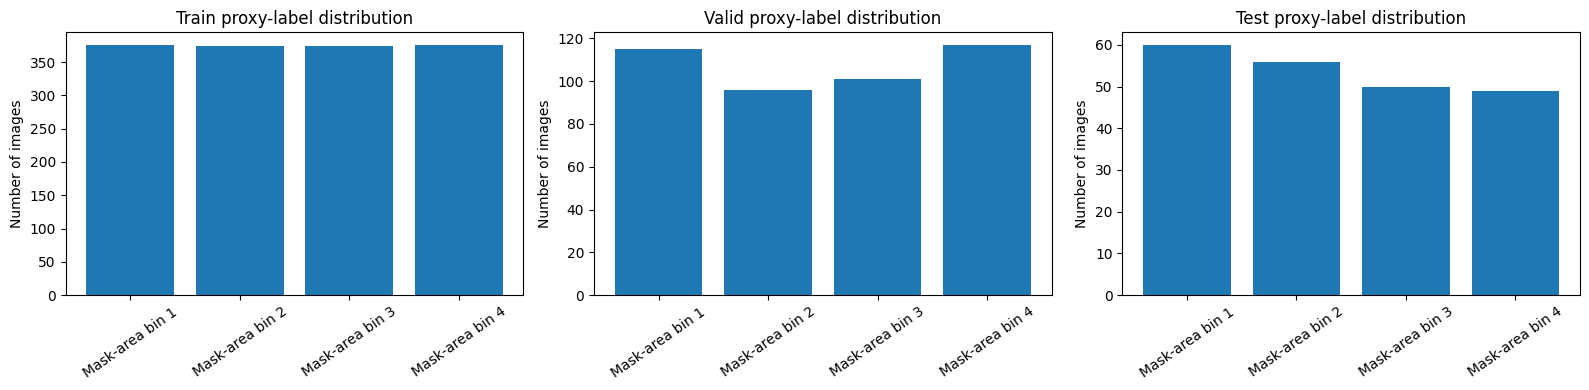

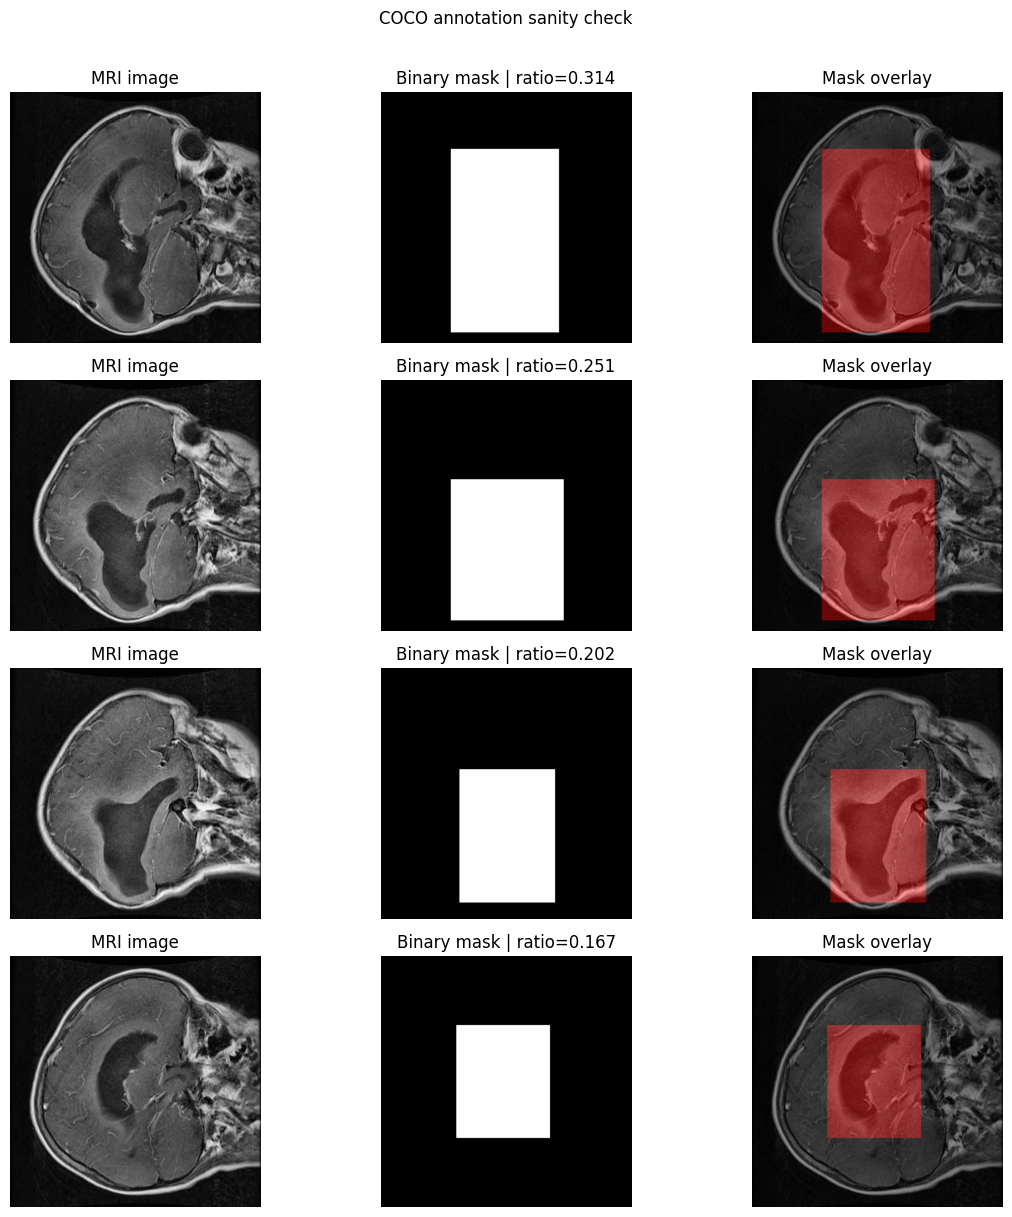

In [3]:
# ============================================================
# Cell 3: Visualise the proxy classes and sample masks
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, (split, frame) in zip(axes, frames.items()):
    counts = frame["target"].value_counts().sort_index()
    labels = [proxy["names"].get(int(index), str(index)) for index in counts.index]
    axis.bar(labels, counts.values)
    axis.set_title(f"{split.capitalize()} proxy-label distribution")
    axis.set_ylabel("Number of images")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


def binary_coco_mask(coco_data: dict, image_id: int) -> np.ndarray:
    """Merge all instance masks for a selected image into one foreground mask."""
    image_info = next(item for item in coco_data["images"] if item["id"] == image_id)
    merged = np.zeros((int(image_info["height"]), int(image_info["width"])), dtype=np.uint8)
    for annotation in coco_data.get("annotations", []):
        if annotation["image_id"] == image_id:
            merged = np.maximum(
                merged,
                polygon_or_rle_to_mask(annotation, merged.shape[0], merged.shape[1]),
            )
    return merged


# Display training samples with the largest annotated foreground regions.
example_count = min(4, len(frames["train"]))
examples = frames["train"].sort_values("mask_ratio", ascending=False).head(example_count)

fig, axes = plt.subplots(example_count, 3, figsize=(12, max(3, 3 * example_count)))
if example_count == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, sample in enumerate(examples.itertuples()):
    image = np.asarray(Image.open(sample.path).convert("RGB"))
    mask = binary_coco_mask(coco_json["train"], sample.image_id)

    axes[row_index, 0].imshow(image, cmap="gray")
    axes[row_index, 0].set_title("MRI image")

    axes[row_index, 1].imshow(mask, cmap="gray")
    axes[row_index, 1].set_title(f"Binary mask | ratio={sample.mask_ratio:.3f}")

    axes[row_index, 2].imshow(image, cmap="gray")
    axes[row_index, 2].imshow(mask, alpha=0.38, cmap=ListedColormap(["black", "red"]))
    axes[row_index, 2].set_title("Mask overlay")

    for column_index in range(3):
        axes[row_index, column_index].axis("off")

plt.suptitle("COCO annotation sanity check", y=1.01)
plt.tight_layout()
plt.show()

## 2. Define rotation and jigsaw pretext datasets

### Why padding is required for the jigsaw task
A \(224\times224\) input cannot be divided evenly into a \(3\times3\) patch grid because \(224 \bmod 3 = 2\). A direct integer split silently reduces the image to \(222\times222\), causing a size mismatch. The function below pads the bottom and right margins to the nearest divisible size, assembles the shuffled image, and crops it back to the original \(224\times224\) size.

In [4]:
# ============================================================
# Cell 4: Transforms and pretext-task Dataset classes
# ============================================================
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# Augmentation used only during pretext training.
# MRI scans are converted to three channels so they can be processed by ResNet-18.
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(cfg.image_size, scale=(0.72, 1.0), antialias=True),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.25, contrast=0.25)], p=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)

# Deterministic transform for validation, frozen-feature extraction, and visual checks.
eval_transform = transforms.Compose(
    [
        transforms.Resize((cfg.image_size, cfg.image_size), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)


def denormalise(tensor: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalisation only for readable visualisation."""
    mean = torch.tensor(MEAN, dtype=tensor.dtype).view(3, 1, 1)
    std = torch.tensor(STD, dtype=tensor.dtype).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


class RotationDataset(Dataset):
    """Return one image with a sampled rotation and its rotation class."""

    def __init__(self, frame: pd.DataFrame, transform, deterministic: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.deterministic = deterministic

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        image_path = self.frame.loc[index, "path"]
        image = self.transform(Image.open(image_path).convert("RGB"))

        # Deterministic validation labels ensure the same validation task each epoch.
        rotation_class = index % 4 if self.deterministic else random.randrange(4)
        rotated_image = torch.rot90(image, rotation_class, dims=(1, 2))
        return rotated_image, rotation_class


def select_separated_permutations(tiles: int, classes: int, seed: int) -> np.ndarray:
    """Choose jigsaw classes that differ strongly in tile locations.

    High Hamming-distance permutations make the pretext classes less ambiguous
    than a collection of nearly identical shuffles.
    """
    if classes > math.factorial(tiles):
        raise ValueError("Requested more jigsaw classes than possible permutations.")

    rng = np.random.default_rng(seed)
    candidate_count = max(4000, classes * 50)
    candidates = np.unique(
        np.stack([rng.permutation(tiles) for _ in range(candidate_count)]), axis=0
    )

    chosen = [np.arange(tiles, dtype=np.int64)]
    while len(chosen) < classes:
        # Calculate the minimum Hamming distance to any already selected permutation.
        distances = np.stack([(candidates != item).sum(axis=1) for item in chosen]).min(axis=0)
        best_index = int(np.argmax(distances))
        best_candidate = candidates[best_index]

        # This safeguard avoids selecting the same permutation twice.
        if any(np.array_equal(best_candidate, selected) for selected in chosen):
            candidates = np.delete(candidates, best_index, axis=0)
            continue
        chosen.append(best_candidate.astype(np.int64))

    return np.stack(chosen)


permutations = select_separated_permutations(
    tiles=cfg.jigsaw_grid ** 2,
    classes=cfg.jigsaw_classes,
    seed=cfg.seed,
)


def shuffle_tiles_preserve_shape(
    image: torch.Tensor, permutation: np.ndarray, grid: int
) -> torch.Tensor:
    """Shuffle image tiles while retaining the original tensor height and width.

    Fix applied here:
    - For 224 pixels and a 3x3 puzzle, two pixels of padding are added.
    - The padded image is divided into equal patches.
    - After shuffling, the result is cropped back to its original size.
    """
    channels, original_height, original_width = image.shape
    pad_height = (grid - original_height % grid) % grid
    pad_width = (grid - original_width % grid) % grid

    # Reflect padding avoids introducing a constant black border at puzzle edges.
    padded = F.pad(image, (0, pad_width, 0, pad_height), mode="reflect")
    _, padded_height, padded_width = padded.shape
    patch_height = padded_height // grid
    patch_width = padded_width // grid

    # Produce a tensor of shape: (number_of_tiles, channels, patch_height, patch_width).
    patches = (
        padded.unfold(1, patch_height, patch_height)
        .unfold(2, patch_width, patch_width)
        .permute(1, 2, 0, 3, 4)
        .reshape(grid * grid, channels, patch_height, patch_width)
    )

    permutation_tensor = torch.as_tensor(permutation, dtype=torch.long)
    shuffled_patches = patches[permutation_tensor]

    # Reassemble the patches, then return the original network input dimensions.
    shuffled_image = (
        shuffled_patches.reshape(grid, grid, channels, patch_height, patch_width)
        .permute(2, 0, 3, 1, 4)
        .reshape(channels, padded_height, padded_width)
    )
    return shuffled_image[:, :original_height, :original_width]


class JigsawDataset(Dataset):
    """Return one shuffled-patch image and the selected permutation class."""

    def __init__(self, frame: pd.DataFrame, transform, deterministic: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.deterministic = deterministic

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        image_path = self.frame.loc[index, "path"]
        image = self.transform(Image.open(image_path).convert("RGB"))

        if self.deterministic:
            permutation_class = index % len(permutations)
        else:
            permutation_class = random.randrange(len(permutations))

        puzzle_image = shuffle_tiles_preserve_shape(
            image, permutations[permutation_class], cfg.jigsaw_grid
        )
        return puzzle_image, permutation_class


rotation_train = RotationDataset(frames["train"], train_transform)
rotation_valid = RotationDataset(frames["valid"], eval_transform, deterministic=True)
jigsaw_train = JigsawDataset(frames["train"], train_transform)
jigsaw_valid = JigsawDataset(frames["valid"], eval_transform, deterministic=True)

# These assertions directly verify the defect fixed in this revision.
expected_shape = (3, cfg.image_size, cfg.image_size)
assert rotation_train[0][0].shape == expected_shape
assert jigsaw_train[0][0].shape == expected_shape
assert permutations.shape == (cfg.jigsaw_classes, cfg.jigsaw_grid ** 2)

print("Pretext dataset checks passed.")
print("Rotation image shape:", tuple(rotation_train[0][0].shape))
print("Jigsaw image shape after padding and crop:", tuple(jigsaw_train[0][0].shape))

Pretext dataset checks passed.
Rotation image shape: (3, 224, 224)
Jigsaw image shape after padding and crop: (3, 224, 224)


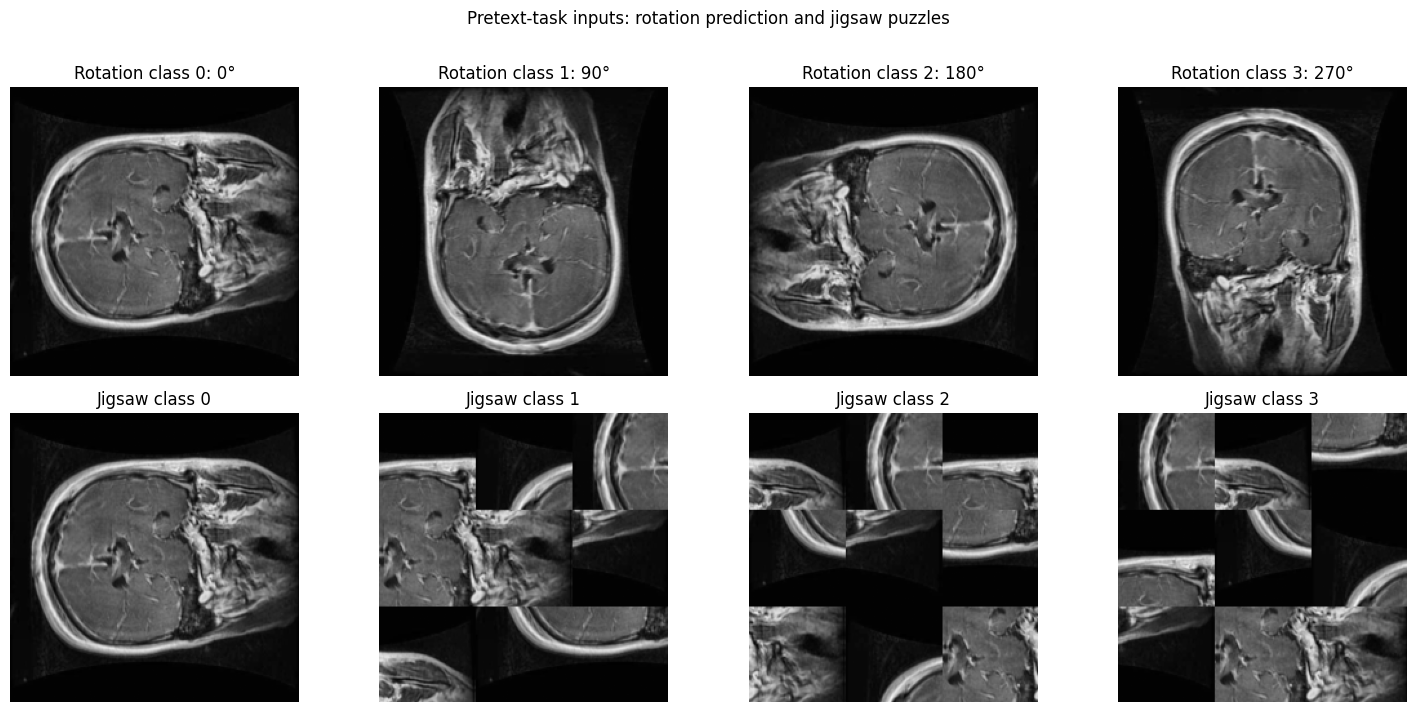

In [5]:
# ============================================================
# Cell 5: Visual sanity check for the two pretext tasks
# ============================================================
source_image = eval_transform(Image.open(frames["train"].iloc[0]["path"]).convert("RGB"))

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for class_index in range(4):
    rotated = torch.rot90(source_image, class_index, dims=(1, 2))
    puzzle = shuffle_tiles_preserve_shape(
        source_image, permutations[class_index], cfg.jigsaw_grid
    )

    axes[0, class_index].imshow(denormalise(rotated).permute(1, 2, 0))
    axes[0, class_index].set_title(f"Rotation class {class_index}: {class_index * 90}°")

    axes[1, class_index].imshow(denormalise(puzzle).permute(1, 2, 0))
    axes[1, class_index].set_title(f"Jigsaw class {class_index}")

    axes[0, class_index].axis("off")
    axes[1, class_index].axis("off")

plt.suptitle("Pretext-task inputs: rotation prediction and jigsaw puzzles", y=1.01)
plt.tight_layout()
plt.show()

## 3. ResNet-18 encoder and pretext training functions

Each pretext model contains:

- a **ResNet-18 encoder** that produces a 512-dimensional representation;
- a task-specific linear head for either 4 rotation classes or the selected jigsaw classes.

Only the encoder is retained for frozen-feature evaluation.

In [6]:
# ============================================================
# Cell 6: Model, DataLoader, optimisation, and training loop
# ============================================================
class PretextModel(nn.Module):
    """ResNet-18 encoder followed by a temporary pretext classification head."""

    def __init__(self, number_of_classes: int):
        super().__init__()
        self.encoder = resnet18(weights=None)
        self.feature_dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()  # Expose the 512-dimensional representation.
        self.head = nn.Linear(self.feature_dim, number_of_classes)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.encoder(images)
        return self.head(features)


def make_loader(dataset: Dataset, shuffle: bool, batch_size: Optional[int] = None) -> DataLoader:
    """Create a Kaggle-friendly DataLoader with GPU-transfer optimisations."""
    effective_batch_size = batch_size or cfg.batch_size
    loader_arguments = {
        "dataset": dataset,
        "batch_size": effective_batch_size,
        "shuffle": shuffle,
        "num_workers": cfg.num_workers,
        "pin_memory": device.type == "cuda",
        # Do not discard data when the split is smaller than a full mini-batch.
        "drop_last": shuffle and len(dataset) >= effective_batch_size,
    }

    # persistent_workers and prefetch_factor are valid only with worker processes.
    if cfg.num_workers > 0:
        loader_arguments.update({"persistent_workers": True, "prefetch_factor": 2})

    return DataLoader(**loader_arguments)


def transfer_images(images: torch.Tensor) -> torch.Tensor:
    """Move an image mini-batch to GPU and use channels-last memory layout where useful."""
    images = images.to(device, non_blocking=True)
    if device.type == "cuda":
        images = images.contiguous(memory_format=torch.channels_last)
    return images


def autocast_context():
    """Use float16 mixed precision only when a CUDA GPU is available."""
    if amp_enabled:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def create_grad_scaler():
    """Support both recent and older PyTorch GradScaler interfaces."""
    try:
        return torch.amp.GradScaler("cuda", enabled=amp_enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def create_optimizer(parameters):
    """Use fused AdamW where supported by the active CUDA/PyTorch combination."""
    try:
        return torch.optim.AdamW(
            parameters,
            lr=cfg.learning_rate,
            weight_decay=cfg.weight_decay,
            fused=(device.type == "cuda"),
        )
    except (TypeError, RuntimeError):
        return torch.optim.AdamW(
            parameters, lr=cfg.learning_rate, weight_decay=cfg.weight_decay
        )


def run_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer=None,
    scaler=None,
    progress_label: str = "",
):
    """Train or evaluate one epoch and return mean loss and classification accuracy."""
    is_training = optimizer is not None
    model.train(is_training)

    total_loss, total_correct, total_images = 0.0, 0, 0

    for images, labels in tqdm(data_loader, desc=progress_label, leave=False):
        images = transfer_images(images)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with autocast_context():
                logits = model(images)
                loss = criterion(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_images += batch_size

    return total_loss / total_images, total_correct / total_images


def fit_pretext_model(
    task_name: str,
    number_of_classes: int,
    training_dataset: Dataset,
    validation_dataset: Dataset,
    epochs: int,
):
    """Train one pretext model and restore the checkpoint with the best validation accuracy."""
    raw_model = PretextModel(number_of_classes).to(device)
    if device.type == "cuda":
        raw_model = raw_model.to(memory_format=torch.channels_last)

    # Compilation is intentionally disabled by default so the notebook starts predictably.
    training_model = (
        torch.compile(raw_model)
        if cfg.compile_model and hasattr(torch, "compile")
        else raw_model
    )

    optimizer = create_optimizer(raw_model.parameters())
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    scaler = create_grad_scaler()
    criterion = nn.CrossEntropyLoss()

    best_accuracy = -1.0
    best_state = None
    history_rows = []

    train_loader = make_loader(training_dataset, shuffle=True)
    valid_loader = make_loader(validation_dataset, shuffle=False)

    for epoch in tqdm(range(1, epochs + 1), desc=f"{task_name} epochs"):
        train_loss, train_accuracy = run_one_epoch(
            training_model,
            train_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
            progress_label=f"{task_name} train {epoch}/{epochs}",
        )
        valid_loss, valid_accuracy = run_one_epoch(
            training_model,
            valid_loader,
            criterion,
            progress_label=f"{task_name} valid {epoch}/{epochs}",
        )
        scheduler.step()

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "train_accuracy": train_accuracy,
                "valid_accuracy": valid_accuracy,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        if valid_accuracy > best_accuracy:
            best_accuracy = valid_accuracy
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in raw_model.state_dict().items()
            }

    raw_model.load_state_dict(best_state)
    history = pd.DataFrame(history_rows)
    print(f"{task_name}: best validation accuracy = {best_accuracy:.4f}")
    return raw_model, history


def plot_training_history(history: pd.DataFrame, task_title: str) -> None:
    """Plot loss and accuracy curves for instructional interpretation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="Train")
    axes[0].plot(history["epoch"], history["valid_loss"], marker="o", label="Validation")
    axes[0].set_title(f"{task_title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_accuracy"], marker="o", label="Train")
    axes[1].plot(history["epoch"], history["valid_accuracy"], marker="o", label="Validation")
    axes[1].set_title(f"{task_title}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# One forward pass catches dimensional or device errors before a full training run begins.
test_model = PretextModel(4).to(device)
with torch.inference_mode():
    test_batch = torch.stack([rotation_train[0][0], rotation_train[1][0]])
    test_logits = test_model(transfer_images(test_batch))
assert test_logits.shape == (2, 4)

del test_model, test_batch, test_logits
if device.type == "cuda":
    torch.cuda.empty_cache()
print("Forward-pass model check passed.")

Forward-pass model check passed.


## 4. Train the rotation-prediction encoder

Rotation prediction epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Rotation prediction train 1/10:   0%|          | 0/23 [00:00<?, ?it/s]

Rotation prediction valid 1/10:   0%|          | 0/7 [00:00<?, ?it/s]

Rotation prediction train 2/10:   0%|          | 0/23 [00:00<?, ?it/s]

Rotation prediction valid 2/10:   0%|          | 0/7 [00:00<?, ?it/s]

...

Rotation prediction train 9/10:   0%|          | 0/23 [00:00<?, ?it/s]

Rotation prediction valid 9/10:   0%|          | 0/7 [00:00<?, ?it/s]

Rotation prediction train 10/10:   0%|          | 0/23 [00:00<?, ?it/s]

Rotation prediction valid 10/10:   0%|          | 0/7 [00:00<?, ?it/s]

Rotation prediction: best validation accuracy = 0.6597


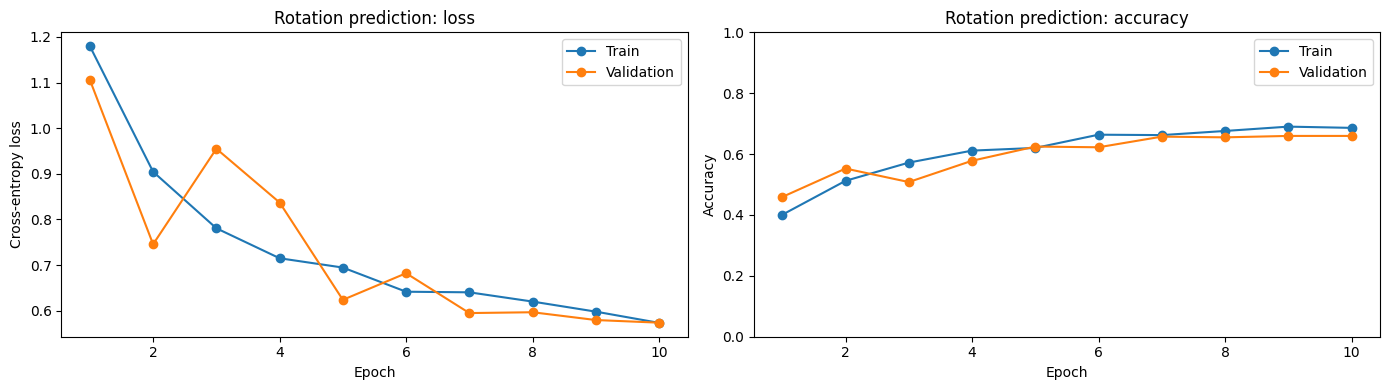

Saved: /kaggle/working/nb01_ssl_outputs/nb01_rotation_resnet18.pt
Saved: /kaggle/working/nb01_ssl_outputs/rotation_training_history.csv


In [7]:
# ============================================================
# Cell 7: Rotation-prediction pretext training
# ============================================================
rotation_model, rotation_history = fit_pretext_model(
    task_name="Rotation prediction",
    number_of_classes=4,
    training_dataset=rotation_train,
    validation_dataset=rotation_valid,
    epochs=cfg.rotation_epochs,
)

plot_training_history(rotation_history, "Rotation prediction")

rotation_checkpoint = OUTPUT_DIR / "nb01_rotation_resnet18.pt"
rotation_history_path = OUTPUT_DIR / "rotation_training_history.csv"
torch.save(rotation_model.state_dict(), rotation_checkpoint)
rotation_history.to_csv(rotation_history_path, index=False)

print("Saved:", rotation_checkpoint)
print("Saved:", rotation_history_path)

## 5. Train the jigsaw-puzzle encoder

Jigsaw puzzle epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Jigsaw puzzle train 1/10:   0%|          | 0/23 [00:00<?, ?it/s]

Jigsaw puzzle valid 1/10:   0%|          | 0/7 [00:00<?, ?it/s]

Jigsaw puzzle train 2/10:   0%|          | 0/23 [00:00<?, ?it/s]

Jigsaw puzzle valid 2/10:   0%|          | 0/7 [00:00<?, ?it/s]

...

Jigsaw puzzle train 9/10:   0%|          | 0/23 [00:00<?, ?it/s]

Jigsaw puzzle valid 9/10:   0%|          | 0/7 [00:00<?, ?it/s]

Jigsaw puzzle train 10/10:   0%|          | 0/23 [00:00<?, ?it/s]

Jigsaw puzzle valid 10/10:   0%|          | 0/7 [00:00<?, ?it/s]

Jigsaw puzzle: best validation accuracy = 1.0000


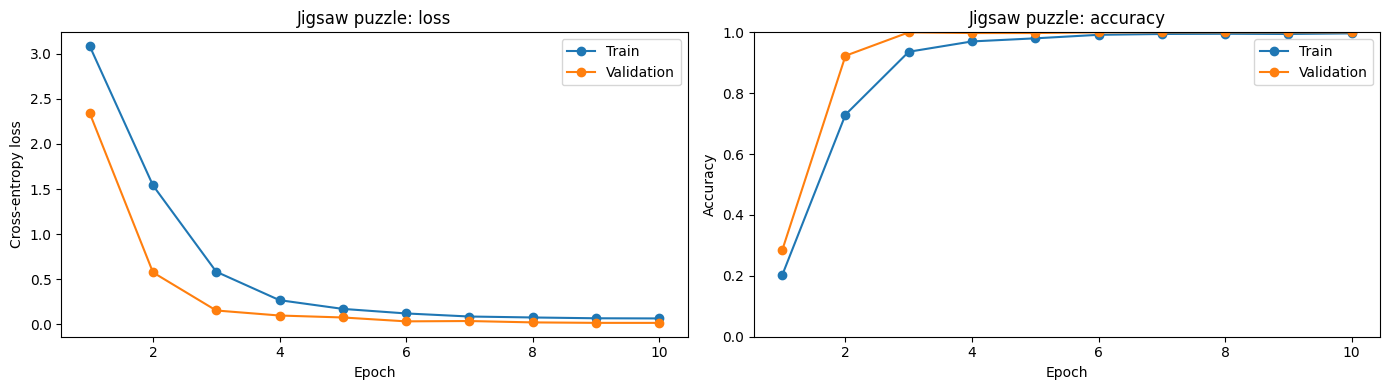

Saved: /kaggle/working/nb01_ssl_outputs/nb01_jigsaw_resnet18.pt
Saved: /kaggle/working/nb01_ssl_outputs/jigsaw_training_history.csv


In [8]:
# ============================================================
# Cell 8: Jigsaw-puzzle pretext training
# ============================================================
jigsaw_model, jigsaw_history = fit_pretext_model(
    task_name="Jigsaw puzzle",
    number_of_classes=cfg.jigsaw_classes,
    training_dataset=jigsaw_train,
    validation_dataset=jigsaw_valid,
    epochs=cfg.jigsaw_epochs,
)

plot_training_history(jigsaw_history, "Jigsaw puzzle")

jigsaw_checkpoint = OUTPUT_DIR / "nb01_jigsaw_resnet18.pt"
jigsaw_history_path = OUTPUT_DIR / "jigsaw_training_history.csv"
torch.save(jigsaw_model.state_dict(), jigsaw_checkpoint)
jigsaw_history.to_csv(jigsaw_history_path, index=False)

print("Saved:", jigsaw_checkpoint)
print("Saved:", jigsaw_history_path)

## 6. Frozen-feature evaluation using k-NN

The encoder is frozen after pretext training. For every image, it produces a representation vector. A k-NN classifier is fitted on training representations and evaluated on validation and test representations.

Three encoders are compared fairly:

1. randomly initialised ResNet-18;
2. rotation-pretrained ResNet-18;
3. jigsaw-pretrained ResNet-18.

Extracting frozen features:   0%|          | 0/24 [00:00<?, ?it/s]

Extracting frozen features:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting frozen features:   0%|          | 0/4 [00:00<?, ?it/s]


Random initialisation | test-set classification report
              precision    recall  f1-score   support

           0       0.65      0.53      0.59        60
           1       0.62      0.41      0.49        56
           2       0.38      0.38      0.38        50
           3       0.51      0.82      0.62        49

    accuracy                           0.53       215
   macro avg       0.54      0.54      0.52       215
weighted avg       0.55      0.53      0.52       215



Extracting frozen features:   0%|          | 0/24 [00:00<?, ?it/s]

...

Extracting frozen features:   0%|          | 0/7 [00:02<?, ?it/s]

^ 
^^   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^ assert self._parent_pid == os.getpid(), 'can only test a child process'^^ 
^^^^ ^^^ ^ ^^^ ^ ^^ ^^^^^ ^
^ ^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
 
^     assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^ 
^    ^ ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
 
 ^ ^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      ^  assert self._parent_pid == os.getpid(), 'can only test a child process'^ ^ 
 ^   ^     ^    ^  ^ ^^ ^^^ ^ ^^^^^^ ^ ^^^^ ^^^ ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^^^^^AssertionError^: ^^^can only test a child process^^^^^
^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c5d8be994e0>^^
^^Traceback (most recent call last):
^^  File "/us

Extracting frozen features:   0%|          | 0/4 [00:00<?, ?it/s]


Jigsaw puzzle | test-set classification report
              precision    recall  f1-score   support

           0       0.52      0.47      0.49        60
           1       0.46      0.34      0.39        56
           2       0.33      0.32      0.33        50
           3       0.50      0.73      0.60        49

    accuracy                           0.46       215
   macro avg       0.45      0.47      0.45       215
weighted avg       0.46      0.46      0.45       215



,encoder,split,accuracy,balanced_accuracy,macro_f1
0,Random initialisation,valid,0.4965,0.4866,0.4861
1,Random initialisation,test,0.5302,0.5351,0.5217
2,Rotation prediction,valid,0.4685,0.4605,0.4633
3,Rotation prediction,test,0.4977,0.5012,0.4900
4,Jigsaw puzzle,valid,0.4359,0.4265,0.4248
5,Jigsaw puzzle,test,0.4605,0.4652,0.4511


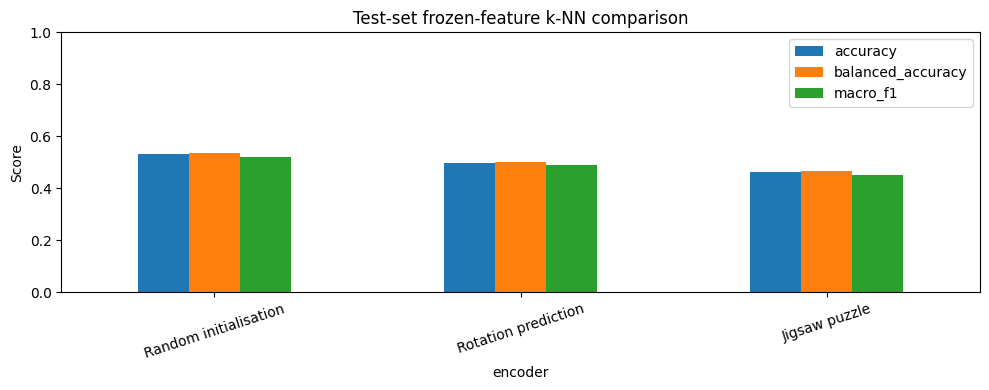

Saved: /kaggle/working/nb01_ssl_outputs/knn_frozen_feature_results.csv


In [9]:
# ============================================================
# Cell 9: Extract frozen representations and run k-NN
# ============================================================
class EvaluationDataset(Dataset):
    """Return deterministic images with the proxy target used for evaluation only."""

    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image = eval_transform(Image.open(row.path).convert("RGB"))
        return image, int(row.target)


@torch.inference_mode()
def extract_features(encoder: nn.Module, frame: pd.DataFrame):
    """Create L2-normalised frozen encoder features for one split."""
    encoder.eval()
    feature_batches, label_batches = [], []

    data_loader = make_loader(EvaluationDataset(frame), shuffle=False)
    for images, labels in tqdm(data_loader, desc="Extracting frozen features", leave=False):
        embeddings = encoder(transfer_images(images)).float()
        embeddings = F.normalize(embeddings, dim=1)
        feature_batches.append(embeddings.cpu().numpy())
        label_batches.append(labels.numpy())

    return np.concatenate(feature_batches), np.concatenate(label_batches)


def evaluate_with_knn(encoder_name: str, encoder: nn.Module):
    """Fit k-NN on training features and evaluate it on fixed hold-out splits."""
    x_train, y_train = extract_features(encoder, frames["train"])
    x_valid, y_valid = extract_features(encoder, frames["valid"])
    x_test, y_test = extract_features(encoder, frames["test"])

    number_of_neighbours = min(cfg.knn_k, len(x_train))
    classifier = KNeighborsClassifier(
        n_neighbors=number_of_neighbours, metric="cosine", weights="distance"
    )
    classifier.fit(x_train, y_train)

    results = []
    for split_name, features, labels in [
        ("valid", x_valid, y_valid),
        ("test", x_test, y_test),
    ]:
        predictions = classifier.predict(features)
        results.append(
            {
                "encoder": encoder_name,
                "split": split_name,
                "accuracy": accuracy_score(labels, predictions),
                "balanced_accuracy": balanced_accuracy_score(labels, predictions),
                "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
            }
        )

        if split_name == "test":
            print(f"\n{encoder_name} | test-set classification report")
            print(classification_report(labels, predictions, zero_division=0))

    return pd.DataFrame(results), (x_test, y_test)


# A random encoder provides the baseline against which pretext learning is compared.
random_model = PretextModel(number_of_classes=4).to(device)
if device.type == "cuda":
    random_model = random_model.to(memory_format=torch.channels_last)

encoders = {
    "Random initialisation": random_model.encoder,
    "Rotation prediction": rotation_model.encoder,
    "Jigsaw puzzle": jigsaw_model.encoder,
}

result_tables = []
test_embeddings = {}
for encoder_name, encoder in encoders.items():
    score_table, test_embedding = evaluate_with_knn(encoder_name, encoder)
    result_tables.append(score_table)
    test_embeddings[encoder_name] = test_embedding

knn_results = pd.concat(result_tables, ignore_index=True)
knn_results_path = OUTPUT_DIR / "knn_frozen_feature_results.csv"
knn_results.to_csv(knn_results_path, index=False)

display(
    knn_results.style.format(
        {"accuracy": "{:.4f}", "balanced_accuracy": "{:.4f}", "macro_f1": "{:.4f}"}
    )
)

test_score_table = knn_results.query("split == 'test'").set_index("encoder")[
    ["accuracy", "balanced_accuracy", "macro_f1"]
]
axis = test_score_table.plot(
    kind="bar", figsize=(10, 4), ylim=(0, 1), title="Test-set frozen-feature k-NN comparison"
)
axis.set_ylabel("Score")
axis.tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

print("Saved:", knn_results_path)

## 7. t-SNE visual comparison of the frozen representations

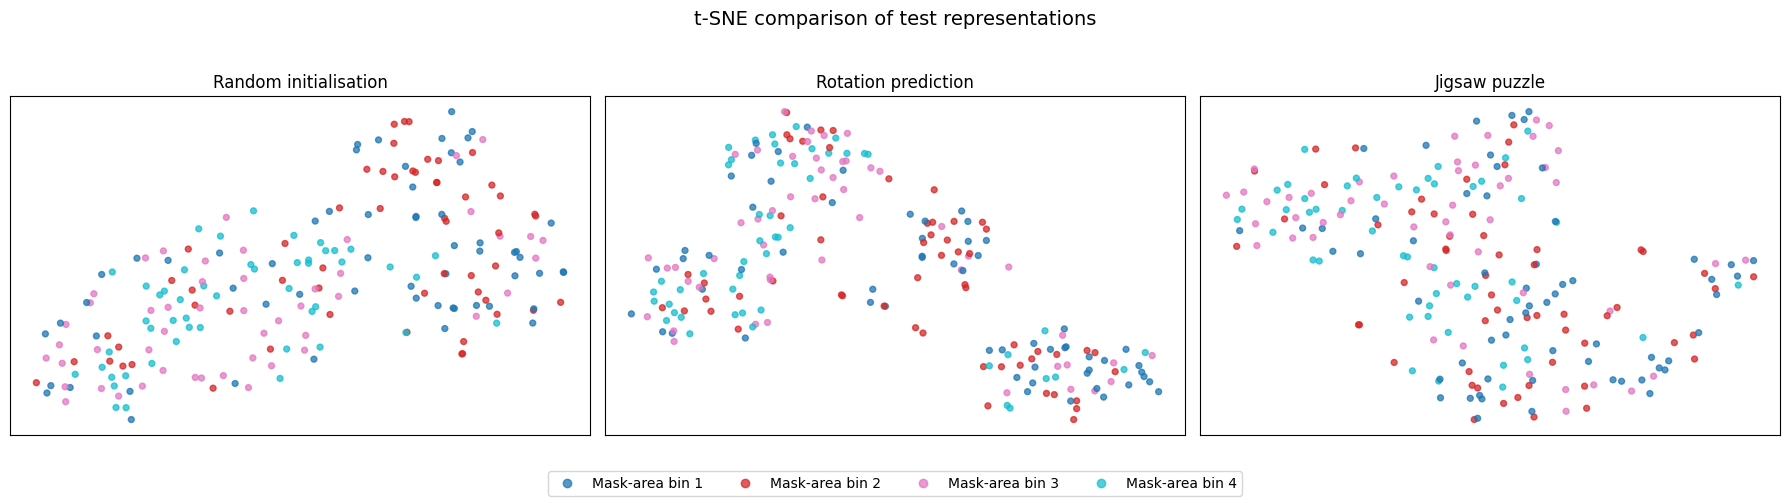

Saved: /kaggle/working/nb01_ssl_outputs/tsne_representation_comparison.png


In [10]:
# ============================================================
# Cell 10: t-SNE visualisation of test feature spaces
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
last_scatter = None

for axis, (encoder_name, (features, labels)) in zip(axes, test_embeddings.items()):
    rng = np.random.default_rng(cfg.seed)
    selected_count = min(cfg.max_tsne_points, len(features))
    selected_indices = rng.choice(len(features), selected_count, replace=False)

    if selected_count < 6:
        axis.text(0.5, 0.5, "Too few examples for t-SNE", ha="center", va="center")
        axis.set_title(encoder_name)
        axis.axis("off")
        continue

    # Perplexity must be smaller than the number of selected samples.
    perplexity = min(30, max(2, (selected_count - 1) // 3))
    perplexity = min(perplexity, selected_count - 1)

    reduced_features = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=cfg.seed,
    ).fit_transform(features[selected_indices])

    last_scatter = axis.scatter(
        reduced_features[:, 0],
        reduced_features[:, 1],
        c=labels[selected_indices],
        cmap="tab10",
        s=18,
        alpha=0.75,
    )
    axis.set_title(encoder_name)
    axis.set_xticks([])
    axis.set_yticks([])

if last_scatter is not None:
    handles, label_values = last_scatter.legend_elements()
    displayed_names = [
        proxy["names"].get(int(float(label)), str(label))
        for label in sorted(np.unique(test_embeddings["Random initialisation"][1]))
    ]
    fig.legend(handles[: len(displayed_names)], displayed_names, loc="lower center", ncol=max(1, len(displayed_names)))

fig.suptitle("t-SNE comparison of test representations", fontsize=14)
plt.tight_layout(rect=(0, 0.10, 1, 0.95))

tsne_figure_path = OUTPUT_DIR / "tsne_representation_comparison.png"
plt.savefig(tsne_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", tsne_figure_path)

## 8. Interpretation guide for students

After execution, report the following items:

1. **Rotation training behaviour:** best validation accuracy and whether validation loss suggests underfitting or overfitting.
2. **Jigsaw training behaviour:** best validation accuracy and whether the selected number of permutations is suitably challenging.
3. **Frozen-feature comparison:** test accuracy, balanced accuracy, and macro-F1 for the random, rotation-pretrained, and jigsaw-pretrained encoders.
4. **t-SNE interpretation:** whether the pretext-trained features exhibit clearer proxy-label structure than random initialisation.
5. **Limitation statement:** mask-presence or mask-area-bin classes are proxy labels for evaluating representations; they are not clinical diagnosis labels.
6. **Next experiment:** attach a segmentation decoder to an encoder and evaluate semantic segmentation using Dice coefficient and IoU.

### Files produced in Kaggle working storage

```text
/kaggle/working/nb01_ssl_outputs/
├── nb01_rotation_resnet18.pt
├── nb01_jigsaw_resnet18.pt
├── rotation_training_history.csv
├── jigsaw_training_history.csv
├── knn_frozen_feature_results.csv
└── tsne_representation_comparison.png
```

---
**Prepared for academic instruction**  
**Dr Md Rifat Ahmmad Rashid**  
Department of CSE, East West University (EWU)